# Delivery Interface and Clinician Response

**Goal.** Model the human in the loop: a scored recommendation is delivered through one of
five presentation actions (interrupt / passive / delay / bundle / suppress), and the clinician
either follows or ignores it. Acceptance erodes as the clinician's recent alert burden grows
(alert fatigue), and each action adds to that burden in proportion to how intrusive it is.

*Illustrative on synthetic data: there is no real clinician-response data yet, so this is a
transparent model of the mechanism, calibrated by hand.*

**What this covers.** The second adherence lever: *presentation*. Even an appropriate recommendation is ignored if surfaced poorly. We model the clinician's response across five presentation actions (interrupt, passive, delay, bundle, suppress) and capture how adherence falls as alert burden accumulates.

**Walk-through.** Deliver the same appropriate recommendation through different actions and watch acceptance trade off against the burden each one adds.

## Pipeline

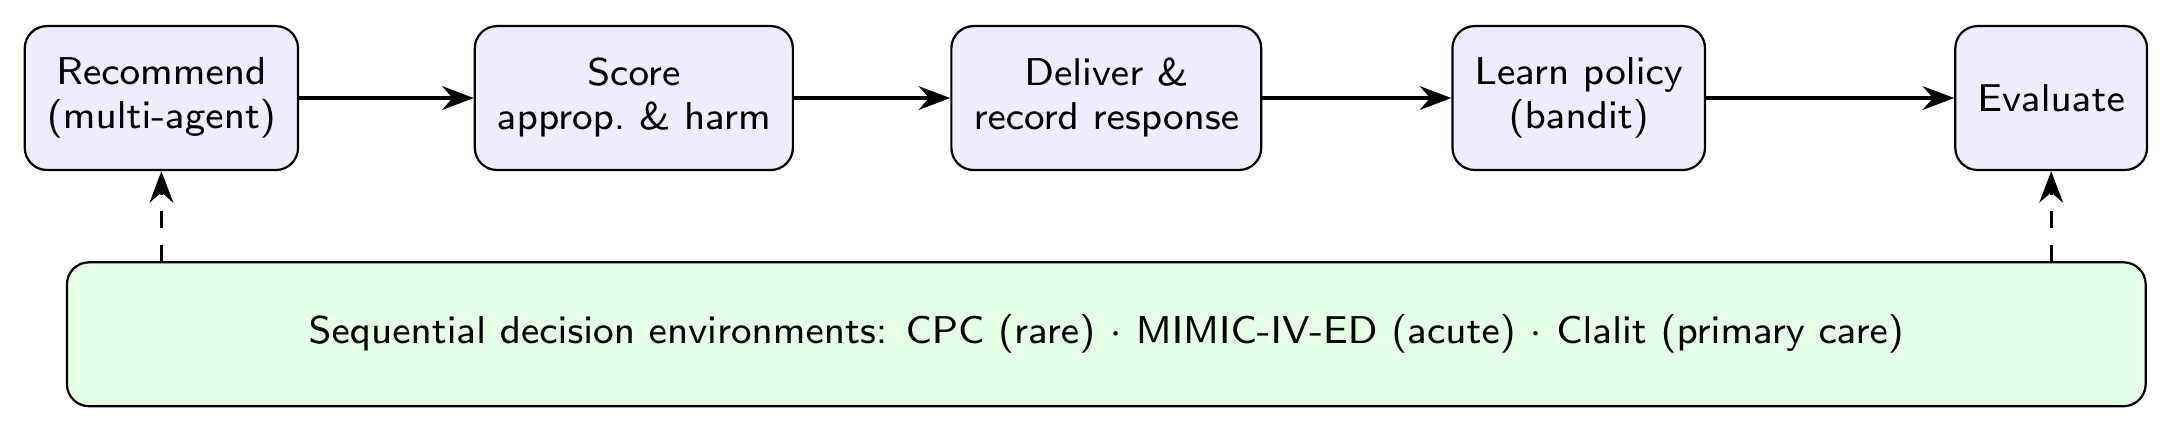

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../03_scoring'))
from IPython.display import Image
Image(filename='../../research_plan/figs/fig-1.png')

## Prior work and limitations

- **AHRQ PSNet 2019, *Alert Fatigue*.** Clinicians override most CDS alerts; volume erodes
  responsiveness, the effect we encode.
- **Park et al. 2022.** Acceptance depends on appropriateness and on the current alert load.
- **Goh et al. 2024 (RCT).** LLM influence on physician reasoning is real but partial, so the
  response must be modeled rather than assumed.
- **FDA 2022, CDS guidance.** Delivery design has regulatory weight; the human stays in the loop.

![paper figure](../shared/paper_figs/fig6_interface.png)

*Figure: clinician interface from the reference work (Nori et al. 2025).*

## Approach

Most diagnostic-LLM evaluations stop at accuracy and assume the recommendation is acted on. We
close the loop with a clinician-response model over the five presentation actions:

- Each action trades **salience against burden**: interrupting is most likely to be acted on but
  adds the most fatigue; a passive note adds little burden but is often missed.
- Fatigue **recovers over time** and **accumulates** with intrusive delivery, so *when and how*
  to deliver becomes a real lever, which Stage 05 learns.

## Mechanism

**Input:** a scored recommendation (appropriateness, harm) + a chosen action + the clinician's
current burden. **Output:** follow/ignore and the updated burden.

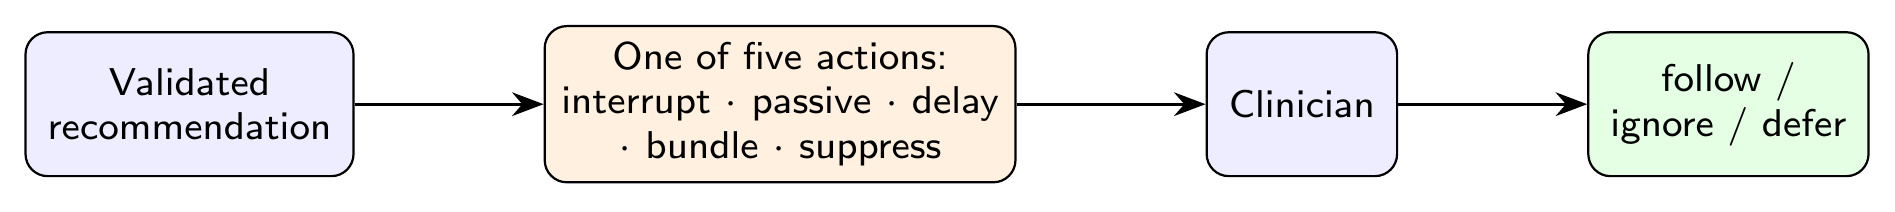

In [2]:
from IPython.display import Image
Image(filename='../../research_plan/figs/fig-5.png')

## Walkthrough
### 1. Same appropriate alert, five different actions
*Expected output:* interrupt has the highest acceptance but the largest burden cost; passive is
the opposite; bundle/delay sit in between. This is the trade-off the policy must navigate.

In [3]:
from shared.toy_data import load_case
from demo_scoring import score_recommendation
from demo_interface import ClinicianSimulator, ACTIONS, BURDEN_ADD
case = load_case('PE-2180')
good = score_recommendation(case, 'CT pulmonary angiogram')
print(f"{'action':<10}{'p(accept)':>11}{'burden_add':>12}")
for action in ACTIONS:
    clin = ClinicianSimulator(seed=1)
    d = clin.respond(good.appropriateness, good.harm, action)
    print(f'{action:<10}{d.p_accept:>11.2f}{BURDEN_ADD[action]:>12.2f}')

action      p(accept)  burden_add
interrupt        0.77        1.00
passive          0.35        0.30
delay            0.54        0.50
bundle           0.66        0.50
suppress         0.00        0.00


### 2. Alert fatigue
*Expected output:* interrupting the same appropriate alert repeatedly drives `p(accept)` down as
burden accumulates, even though the alert is appropriate every time.

In [4]:
clin = ClinicianSimulator(seed=1)
print(f"{'#':>2}{'burden':>8}{'p(accept)':>11}  outcome")
for i in range(1, 8):
    d = clin.respond(good.appropriateness, good.harm, 'interrupt')
    print(f"{i:>2}{d.burden:>8.1f}{d.p_accept:>11.2f}  {'ACCEPT' if d.accepted else 'DISMISS'}")

 #  burden  p(accept)  outcome
 1     1.0       0.77  ACCEPT
 2     1.8       0.60  DISMISS
 3     2.4       0.45  DISMISS
 4     3.0       0.32  ACCEPT
 5     3.4       0.24  DISMISS
 6     3.7       0.19  DISMISS
 7     4.0       0.15  DISMISS


### 3. Mixing in lighter actions keeps responsiveness
*Expected input:* the same alert, but delivered with a quieter action (passive/bundle) or
suppressed, so burden recovers. *Expected output:* lower burden, so later interrupts still land.

In [5]:
clin = ClinicianSimulator(seed=1)
for i, action in enumerate(['interrupt', 'passive', 'suppress', 'bundle', 'suppress', 'interrupt'], 1):
    d = clin.respond(good.appropriateness, good.harm, action)
    tag = ('ACCEPT' if d.accepted else 'DISMISS') if d.delivered else 'suppressed'
    print(f'{i:>2}  {action:<10} burden={d.burden:>4.1f}  {tag}')

 1  interrupt  burden= 1.0  ACCEPT
 2  passive    burden= 1.1  DISMISS
 3  suppress   burden= 0.9  suppressed
 4  bundle     burden= 1.2  DISMISS
 5  suppress   burden= 1.0  suppressed
 6  interrupt  burden= 1.8  ACCEPT


**Next:** Notebook 05 learns *which action* to take in each context. Because each delivery moves
the burden, that is a sequential (MDP) decision, not a one-shot choice.